# Feature visualization: skewness & correlation

Exploratory look at the 831 anatomical features (`x0..x831`) beyond the summary stats in
`notebooks/eda.py`, focused on two things that matter for preprocessing choices:

- **Skewness** — how far each feature's distribution is from symmetric. Very skewed features
  (including the injected noise columns with insane magnitude, see `CLAUDE.md`) can dominate
  distance/variance-based steps (`VarianceThreshold`, `SelectKBest`) if left unscaled/untransformed.
- **Correlation** — both feature-vs-age (which features actually carry signal) and
  feature-vs-feature (redundancy among the top signal features, which a plain `SelectKBest`
  ranking doesn't account for).

Uses raw `X_train` (no imputation) since `.skew()` / `.corr()` skip NaNs by default and we want
to see the *actual* feature distributions, not post-imputation artifacts. Column
names/indices are recomputed here rather than hardcoded, since CLAUDE.md notes they can shift
if the dataset is regenerated.


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

REPO_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
DATA_DIR = os.path.join(REPO_ROOT, "data", "raw")

X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"))
feat_cols = [c for c in X_train.columns if c != "id"]

print(f"X_train: {X_train.shape}, {len(feat_cols)} features")


X_train: (1212, 833), 832 features


## Skewness

Pandas `.skew()` (Fisher-Pearson, adjusted) per feature, computed on raw values.

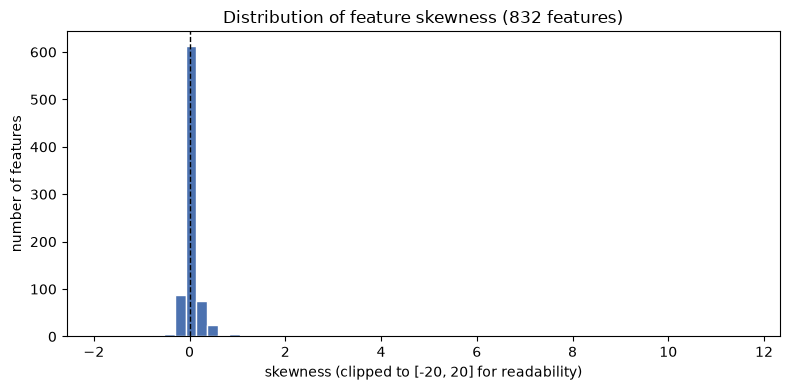

Skewness summary:
count    832.000000
mean       0.078948
std        0.638316
min       -1.890309
25%       -0.044128
50%        0.007498
75%        0.067734
max       11.656317
dtype: float64

Features with |skew| > 5: 3
Features with |skew| < 1 (near-symmetric): 816


In [2]:
skew = X_train[feat_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(skew.clip(-20, 20), bins=60, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("skewness (clipped to [-20, 20] for readability)")
ax.set_ylabel("number of features")
ax.set_title(f"Distribution of feature skewness ({len(feat_cols)} features)")
plt.tight_layout()
plt.show()

print("Skewness summary:")
print(skew.describe())
print(f"\nFeatures with |skew| > 5: {(skew.abs() > 5).sum()}")
print(f"Features with |skew| < 1 (near-symmetric): {(skew.abs() < 1).sum()}")


The tail of extreme |skew| values is expected to line up with the injected noise columns
(huge-magnitude outlier values, see `CLAUDE.md`) rather than genuine anatomical asymmetry —
check below.

Most skewed features:
x665    11.656317
x413    10.194423
x143     5.216660
x641     3.671528
x796     2.904685
x115     2.746024
x742     2.506001
x507     1.940705
x173    -1.890309
x415     1.666279
x159     1.460376
x702     1.393196
dtype: float64


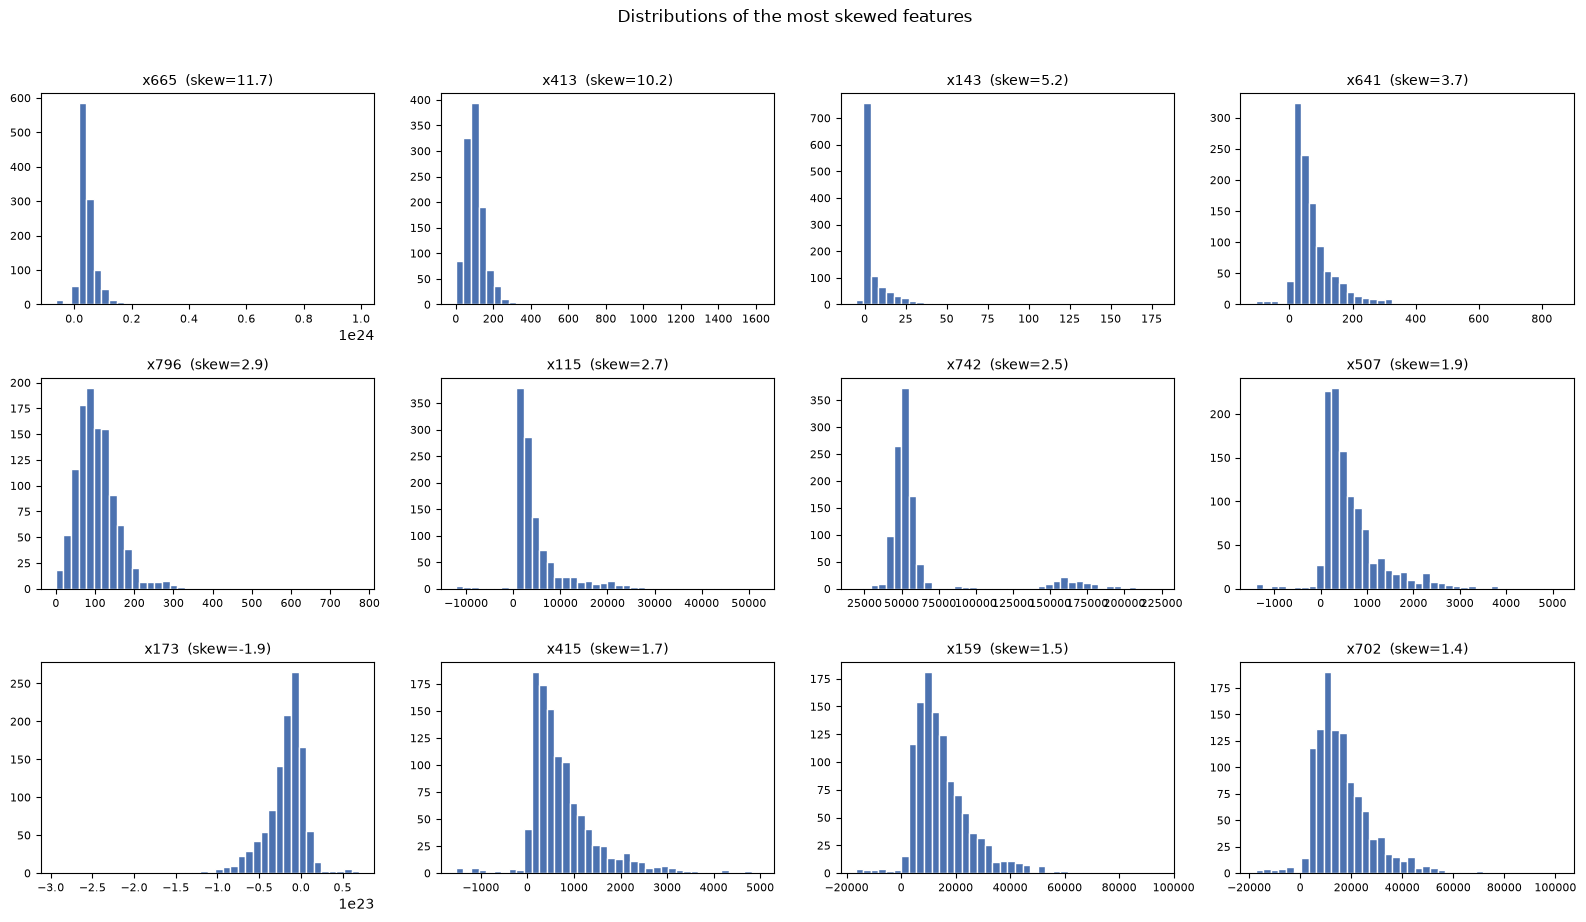

In [3]:
top_skew = skew.head(12)
print("Most skewed features:")
print(top_skew)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.flat, top_skew.index):
    ax.hist(X_train[col].dropna(), bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{col}  (skew={top_skew[col]:.1f})", fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle("Distributions of the most skewed features", y=1.02)
plt.tight_layout()
plt.show()


For contrast, here are features closer to the middle of the skew distribution — these look like
plausible real anatomical measurements (roughly bell-shaped, no extreme tail).

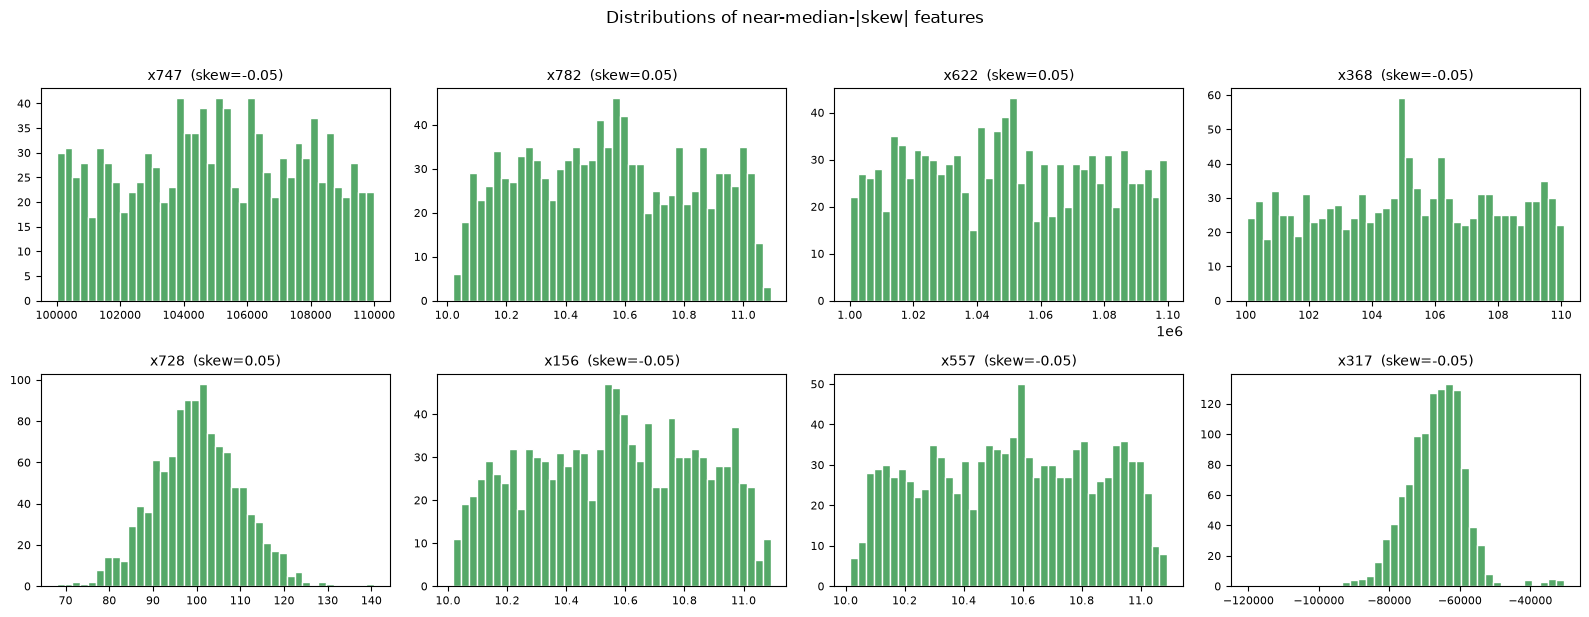

In [4]:
closest_to_median = (skew.abs() - skew.abs().median()).abs().sort_values().index[:8]
mid_skew = skew.loc[closest_to_median]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, mid_skew.index):
    ax.hist(X_train[col].dropna(), bins=40, color="#55A868", edgecolor="white")
    ax.set_title(f"{col}  (skew={mid_skew[col]:.2f})", fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle("Distributions of near-median-|skew| features", y=1.02)
plt.tight_layout()
plt.show()


## Correlation with age

Pearson correlation of each raw feature with the target, matching `eda.py`'s `corrwith` but visualized.

/Users/wojciech.bentkowski/dev/ai/brain-age/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wojciech.bentkowski/dev/ai/brain-age/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


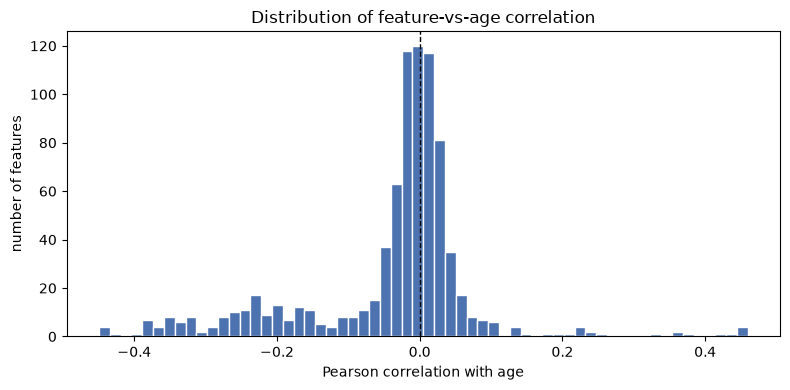

Features with |corr| < 0.02 (near-irrelevant): 309 / 832


In [5]:
target_corr = X_train[feat_cols].corrwith(y_train["y"]).sort_values(key=lambda s: s.abs(), ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(target_corr, bins=60, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Pearson correlation with age")
ax.set_ylabel("number of features")
ax.set_title("Distribution of feature-vs-age correlation")
plt.tight_layout()
plt.show()

print(f"Features with |corr| < 0.02 (near-irrelevant): {(target_corr.abs() < 0.02).sum()} / {len(feat_cols)}")


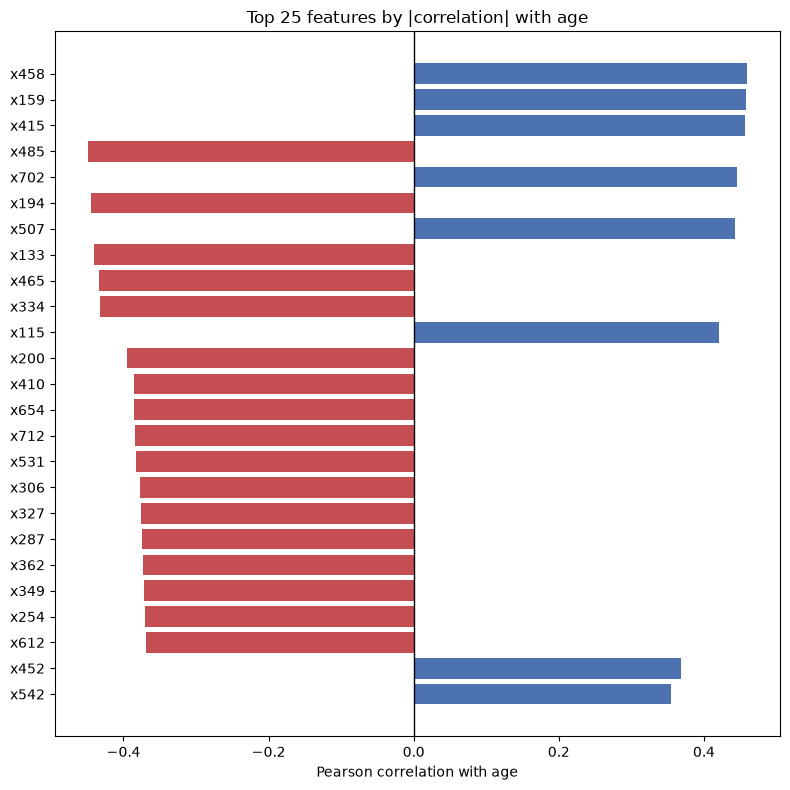

In [6]:
top_n = 25
top_corr = target_corr.head(top_n)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top_corr.values]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Pearson correlation with age")
ax.set_title(f"Top {top_n} features by |correlation| with age")
plt.tight_layout()
plt.show()


Scatter plots of the four strongest age-correlated features, to sanity-check the relationship
looks like a real (if noisy) linear trend rather than an artifact.

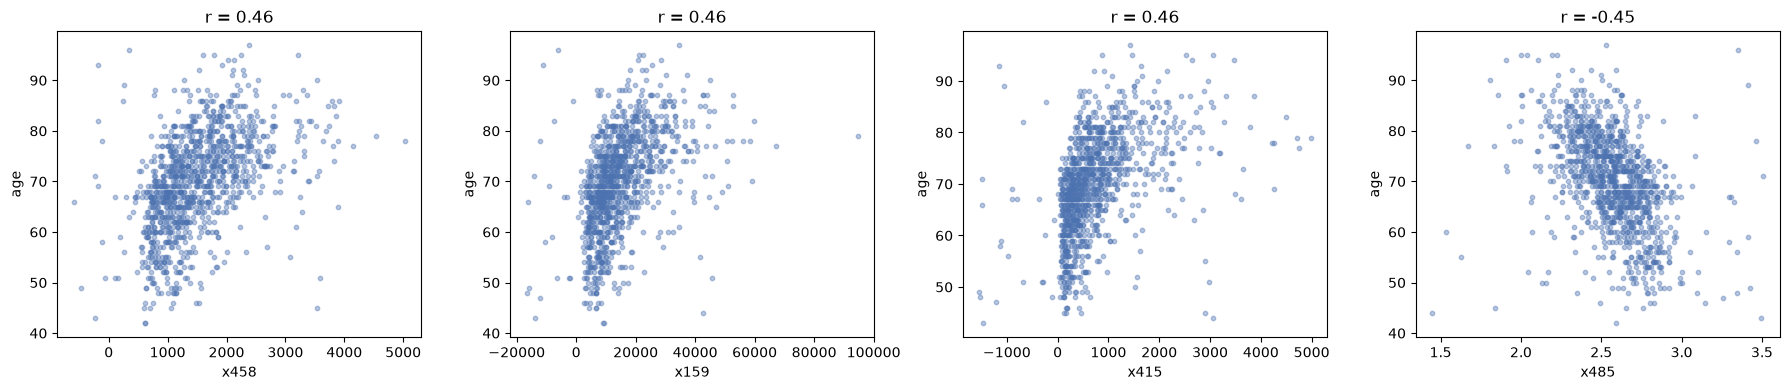

In [7]:
top4 = target_corr.head(4)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, top4.index):
    ax.scatter(X_train[col], y_train["y"], s=10, alpha=0.4, color="#4C72B0")
    ax.set_xlabel(col)
    ax.set_ylabel("age")
    ax.set_title(f"r = {top4[col]:.2f}")
plt.tight_layout()
plt.show()


## Feature-feature correlation (redundancy)

`SelectKBest(f_regression)` ranks features independently by their correlation with age — it has
no notion of *redundancy*, so if several top-ranked features are themselves highly
inter-correlated, the selected set can carry less unique signal than `k=100` distinct features
would suggest. Heatmap below shows pairwise correlation among the top 30 age-correlated
features.

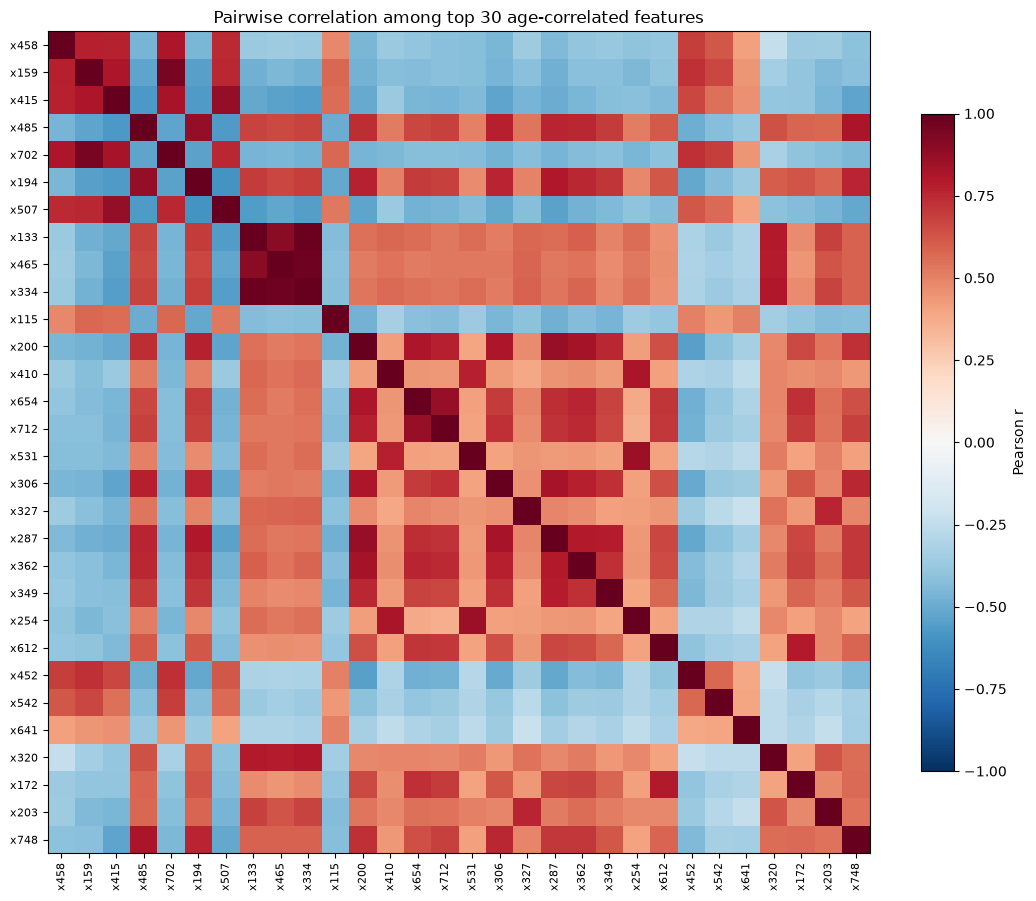

Pairs with |r| > 0.9 among top-30 features: 4
x133  x334    0.977834
x465  x334    0.974138
x159  x702    0.950034
x133  x465    0.902566
dtype: float64


In [8]:
top30_cols = target_corr.head(30).index.tolist()
corr_matrix = X_train[top30_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(top30_cols)))
ax.set_yticks(range(len(top30_cols)))
ax.set_xticklabels(top30_cols, rotation=90, fontsize=8)
ax.set_yticklabels(top30_cols, fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)
ax.set_title("Pairwise correlation among top 30 age-correlated features")
plt.tight_layout()
plt.show()

# upper triangle only (k=1 excludes the diagonal), so each pair is counted once
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
redundant = upper.stack().dropna()
redundant = redundant[redundant.abs() > 0.9].sort_values(key=lambda s: s.abs(), ascending=False)
print(f"Pairs with |r| > 0.9 among top-30 features: {len(redundant)}")
print(redundant)


## Takeaways

- A handful of features have extreme skewness driven by the injected noise columns, not genuine
  anatomical variation — consistent with the huge-magnitude outlier columns flagged in
  `notebooks/eda.py` / `CLAUDE.md`. `RobustScaler` (median/IQR-based) is the right call for these
  rather than a standard scaler.
- Most features cluster near |corr| < 0.02 with age, matching the ~300+ near-irrelevant count
  from `eda.py` — supports keeping `VarianceThreshold` + `SelectKBest` in the pipeline.
- Some of the top age-correlated features are themselves highly inter-correlated, so
  `SelectKBest`'s top-k picks likely include redundant pairs; a redundancy-aware selector
  (e.g. greedy correlation pruning, or `SelectKBest` + a correlation cutoff) could be worth
  benchmarking against the current baseline the way `notebooks/feature_selection_comparison.py`
  benchmarks scoring functions.
